In [1446]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, GammaRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler



import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from dmba import AIC_score
from dmba import stepwise_selection

In [1447]:
house = pd.read_csv("data/House_Rent_Dataset.csv")
house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [1448]:
# BHK: Number of Bedrooms, Hall, Kitchen.
# Rent: Rent of the Houses/Apartments/Flats.
# Size: Size of the Houses/Apartments/Flats in Square Feet.
# Floor: Houses/Apartments/Flats situated in which Floor and Total Number of Floors (Example: Ground out of 2, 3 out of 5, etc.)
# Area Type: Size of the Houses/Apartments/Flats calculated on either Super Area or Carpet Area or Build Area.
# Area Locality: Locality of the Houses/Apartments/Flats.
# City: City where the Houses/Apartments/Flats are Located.
# Furnishing Status: Furnishing Status of the Houses/Apartments/Flats, either it is Furnished or Semi-Furnished or Unfurnished.
# Tenant Preferred: Type of Tenant Preferred by the Owner or Agent.
# Bathroom: Number of Bathrooms.
# Point of Contact: Whom should you contact for more information regarding the Houses/Apartments/Flats.


In [1449]:
house["Tenant Preferred"].value_counts()

Tenant Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

In [1450]:
house["Point of Contact"].value_counts()

Point of Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

In [1451]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [1452]:
house["Posted On"].sort_values()

1222    2022-04-13
244     2022-04-23
418     2022-04-23
303     2022-04-23
413     2022-04-23
           ...    
4368    2022-07-10
4126    2022-07-10
4546    2022-07-10
3743    2022-07-10
3552    2022-07-11
Name: Posted On, Length: 4746, dtype: object

In [1453]:
from datetime import datetime

def day_clasificator(date_string):
    date_object = datetime.strptime(date_string, "%Y-%m-%d")
    return date_object.strftime("%A")


house["day_of_week"] = [day_clasificator(date) for date in house["Posted On"].values]
house.sort_values(by="Posted On")

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week
1222,2022-04-13,3,260000,1800,10 out of 11,Carpet Area,JVPD Scheme,Mumbai,Furnished,Family,4,Contact Agent,Wednesday
244,2022-04-23,2,7000,450,1 out of 3,Carpet Area,safuipara,Kolkata,Furnished,Bachelors,2,Contact Owner,Saturday
418,2022-04-23,1,6500,800,Ground out of 1,Carpet Area,Santragachi,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Saturday
303,2022-04-23,2,20000,700,1 out of 2,Super Area,Salt Lake City Sector 1,Kolkata,Furnished,Bachelors/Family,1,Contact Owner,Saturday
413,2022-04-23,3,36125,1700,Ground out of 2,Super Area,Salt Lake City,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4368,2022-07-10,3,95000,2700,23 out of 30,Carpet Area,Gachibowli,Hyderabad,Furnished,Bachelors,3,Contact Agent,Sunday
4126,2022-07-10,3,50000,2300,2 out of 5,Carpet Area,"Ashok Nagar, Himayath Nagar",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday
4546,2022-07-10,3,67000,2310,3 out of 17,Super Area,Madhapur,Hyderabad,Semi-Furnished,Family,3,Contact Agent,Sunday
3743,2022-07-10,3,15000,1200,2 out of 5,Carpet Area,Madambakkam,Chennai,Unfurnished,Bachelors/Family,2,Contact Agent,Sunday


In [1454]:
house["Floor2"] = ["0" if text.split(" ")[0] == "Ground" 
                    else "-1" if text.split(" ")[0] == "Upper" or text.split(" ")[0] == "Lower"
                    else  text.split(" ")[0]
                    for text in house.Floor]
house.Floor2.value_counts()

Floor2
1     1161
2      945
0      927
3      512
4      272
5      164
6       93
7       74
10      67
8       66
9       65
12      47
11      43
15      41
-1      34
14      34
18      26
17      22
16      21
19      16
13      15
20      12
25      12
23       9
24       6
21       6
30       5
34       4
28       4
27       3
26       3
32       3
60       3
65       3
35       3
22       3
48       2
53       2
45       2
36       2
40       2
29       1
50       1
49       1
39       1
46       1
41       1
44       1
33       1
37       1
47       1
43       1
76       1
Name: count, dtype: int64

In [1455]:
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
        'Bathroom', 'Point of Contact',"day_of_week", "City"]

X = pd.get_dummies(house[predictors], drop_first=True)
y = house.Rent


house_lm = LinearRegression()
house_lm.fit(X, y)

floor_residuals = pd.DataFrame({
    "floor_num": house.Floor2,
    "residual": y - house_lm.predict(X)
})

floor_residuals


,floor_num,residual
0,0,-22481.151648
1,1,15399.023670
2,1,4968.782694
3,1,5934.218796
4,1,-1061.309082
...,...,...
4741,3,-2410.506284
4742,1,-26694.801170
4743,3,-22975.558288
4744,23,5818.407936


In [1456]:
floor_groups = pd.DataFrame([
    {
        "floor": floor,
        "count": len(i),
        "median_residual": i.residual.median()
    }
    for floor, i in floor_residuals.groupby("floor_num")
]).sort_values("median_residual")

floor_groups.sample()

,floor,count,median_residual
42,49,1,-24855.787149


In [1457]:
floor_groups["cum_count"] = np.cumsum(floor_groups["count"])
floor_groups["floor_group"] = pd.qcut(floor_groups.cum_count, 5, labels=False, retbins=False)
floor_groups

,floor,count,median_residual,cum_count,floor_group
25,30,5,-33227.459022,5,0
9,16,21,-26960.091205,26,0
3,10,67,-26143.176960,93,0
6,13,15,-25715.797319,108,0
42,49,1,-24855.787149,109,0
46,6,93,-24703.007535,202,0
41,48,2,-24228.659172,204,0
52,9,65,-24222.971293,269,0
5,12,47,-23510.378406,316,0
8,15,41,-23396.201309,357,0


In [1458]:
to_join = floor_groups[["floor", "floor_group"]].set_index("floor")
house = house.join(to_join, on="Floor2")


In [1459]:
house["floor_group"] = house["floor_group"].astype("category")

In [1460]:
# Extract total floors
house["Total_floors"] = house["Floor"].apply(lambda x: int(x.split(" ")[-1]) if "out of" in x else 1)

# Extract month from Posted On
house["Month"] = pd.to_datetime(house["Posted On"]).dt.month

house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week,Floor2,floor_group,Total_floors,Month
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Wednesday,0,2,2,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Friday,1,2,3,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Monday,1,2,3,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Monday,1,2,2,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,Monday,1,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,Wednesday,3,2,5,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,Sunday,1,2,4,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday,3,2,5,7
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,Wednesday,23,2,34,7


In [1461]:
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & 
                           (df_clean[col] <= Q3 + 1.5*IQR)]
    return df_clean

# # Remove outliers from numerical columns
# numerical_cols = ["Size", "Rent", 'Total_floors',"Month"]
# house = remove_outliers(house, numerical_cols)

def adjusted_r2(y_actual, y_predict, p):
    print("Adjusted R2",1-(1-r2_score(y_actual, y_predict))*(len(y_actual)-1)/(len(y_actual)-p-1))

house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week,Floor2,floor_group,Total_floors,Month
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Wednesday,0,2,2,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Friday,1,2,3,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Monday,1,2,3,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Monday,1,2,2,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,Monday,1,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,Wednesday,3,2,5,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,Sunday,1,2,4,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday,3,2,5,7
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,Wednesday,23,2,34,7


In [1462]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month", "City"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Calculate metrics for both sets
def print_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Metrics:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
MSE: 1847277896.97
RMSE: 42979.97
MAE: 21208.08
R2 Score: 0.5365
Adjusted R2 0.5223949221615469

Cross-validation scores: [ 0.55129507  0.19055452  0.26400282  0.24365718 -0.94940058]
Average CV score: 0.0600 (+/- 1.0403)


In [1463]:
X

,BHK,Size,Bathroom,Total_floors,Month,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,...,day_of_week_Wednesday,floor_group_1,floor_group_2,floor_group_3,floor_group_4,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,2,1100,2,2,5,False,True,False,True,True,...,True,False,True,False,False,False,False,False,True,False
1,2,800,1,3,5,False,True,True,False,True,...,False,False,True,False,False,False,False,False,True,False
2,2,1000,1,3,5,False,True,True,False,True,...,False,False,True,False,False,False,False,False,True,False
3,2,800,1,2,7,False,True,False,True,True,...,False,False,True,False,False,False,False,False,True,False
4,2,850,1,2,5,True,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,1000,2,5,5,True,False,True,False,True,...,True,False,True,False,False,False,False,True,False,False
4742,3,2000,3,4,5,False,True,True,False,True,...,False,False,True,False,False,False,False,True,False,False
4743,3,1750,3,5,7,True,False,True,False,True,...,False,False,True,False,False,False,False,True,False,False
4744,3,1500,2,34,7,True,False,True,False,False,...,True,False,True,False,False,False,False,True,False,False


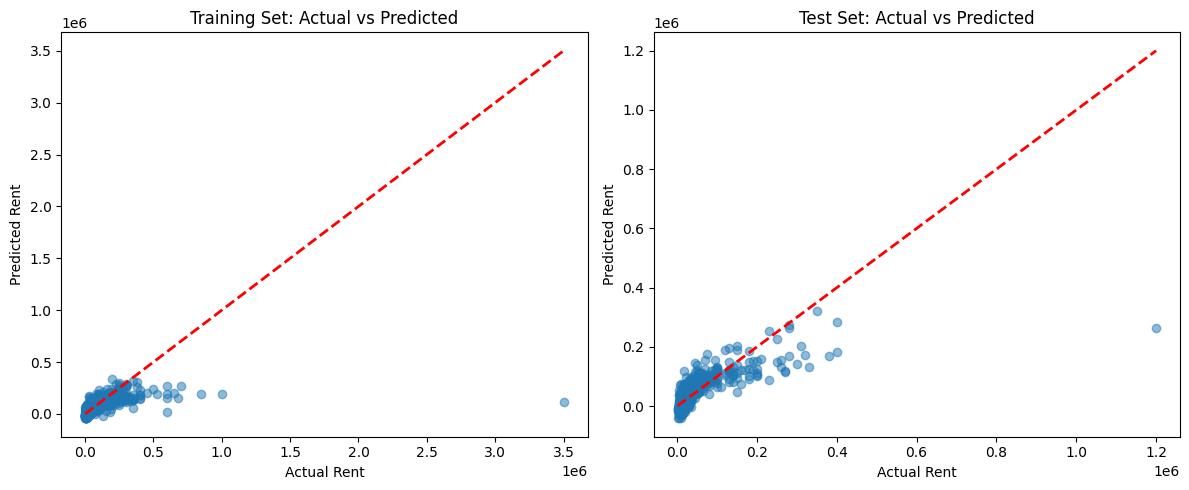

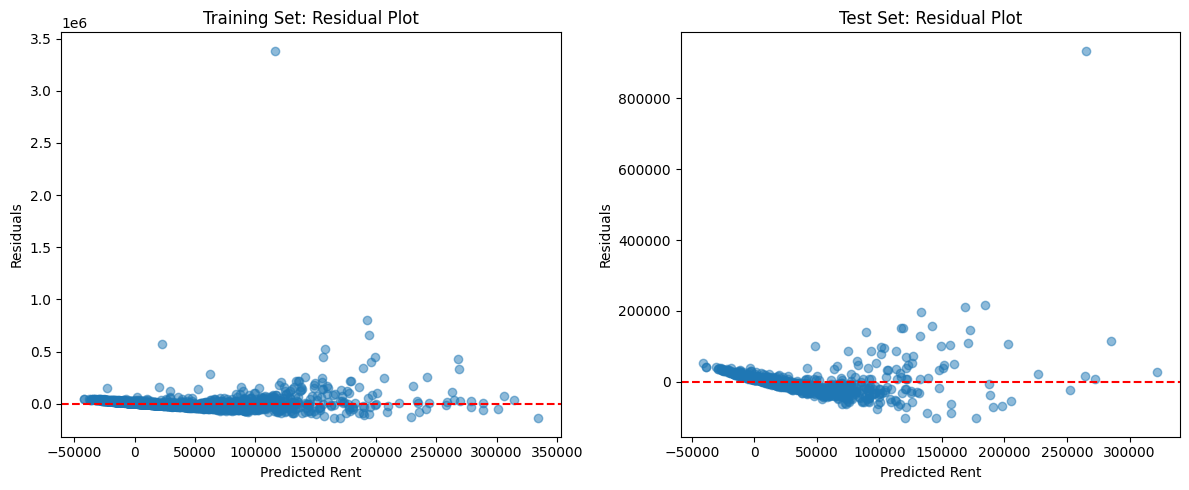

In [1464]:
# Visualization of predictions vs actual values
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Training Set: Actual vs Predicted')

# Test set
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(12, 5))

# Training residuals
plt.subplot(1, 2, 1)
plt.scatter(train_pred, y_train - train_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Training Set: Residual Plot')

# Test residuals
plt.subplot(1, 2, 2)
plt.scatter(test_pred, y_test - test_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Test Set: Residual Plot')

plt.tight_layout()
plt.show()

In [1465]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X_train, y_train))

Lasso(alpha=10)


/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.758e+12, tolerance: 2.516e+09
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.437e+12, tolerance: 2.516e+09
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

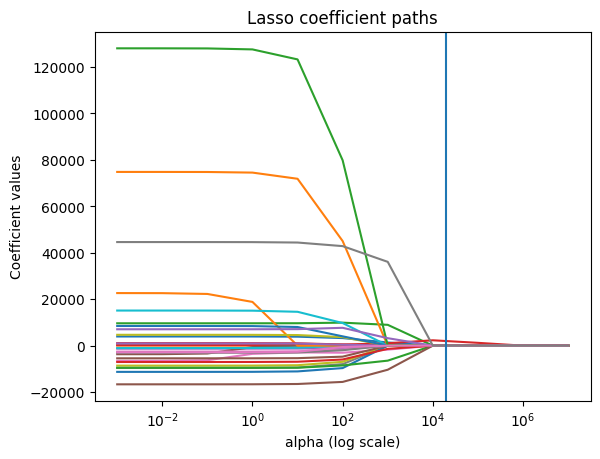

In [1466]:

Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

columns = X_train.columns

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X_train, y_train)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X_train, y_train)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Lasso coefficient paths")
plt.show()

In [1467]:
print_metrics(y_test, modelCV.predict(X_test), "Lasso regularization")


Lasso regularization Metrics:
MSE: 2266282948.60
RMSE: 47605.49
MAE: 22482.05
R2 Score: 0.4314


In [1468]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,BHK,0.000000
1,Size,42.918120
2,Bathroom,0.000000
3,Total_floors,2182.690158
4,Month,0.000000
5,Area Type_Carpet Area,0.000000
6,Area Type_Super Area,-0.000000
7,Furnishing Status_Semi-Furnished,-0.000000
8,Furnishing Status_Unfurnished,-0.000000
9,Tenant Preferred_Bachelors/Family,-0.000000


In [1469]:
print(f'Intercept: {model_main.intercept_:.3f}')

pd.DataFrame({
    "name": X_train.columns,
    "coef": model_main.coef_
})

Intercept: -13376.082


,name,coef
0,BHK,3940.333249
1,Size,36.027736
2,Bathroom,9619.335116
3,Total_floors,198.666575
4,Month,-1284.502183
5,Area Type_Carpet Area,-4617.148536
6,Area Type_Super Area,-7506.754815
7,Furnishing Status_Semi-Furnished,-9609.007908
8,Furnishing Status_Unfurnished,-8597.013003
9,Tenant Preferred_Bachelors/Family,-1048.059583


In [1470]:
print_metrics(y_test, modelCV.predict(X_test), "Train regularization")
adjusted_r2(y_test,modelCV.predict(X_test), X.shape[1])


Train regularization Metrics:
MSE: 2266282948.60
RMSE: 47605.49
MAE: 22482.05
R2 Score: 0.4314
Adjusted R2 0.41406312182602034


In [1471]:
print_metrics(y_test, model_main.predict(X_test), "Train main model")
adjusted_r2(y_test,model_main.predict(X_test), X.shape[1])


Train main model Metrics:
MSE: 1847277896.97
RMSE: 42979.97
MAE: 21208.08
R2 Score: 0.5365
Adjusted R2 0.5223949221615469


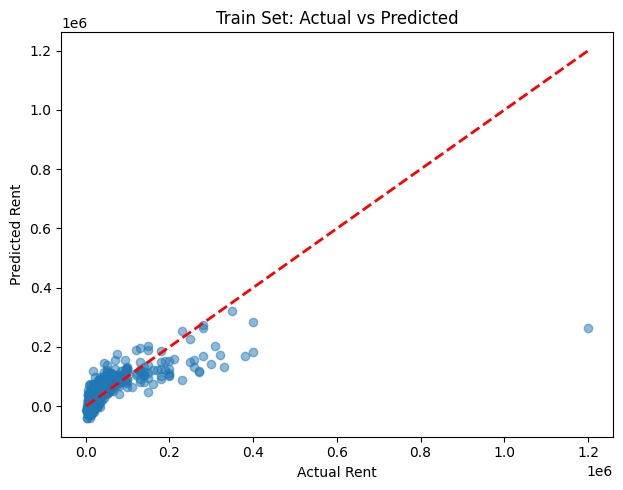

In [1472]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Train Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

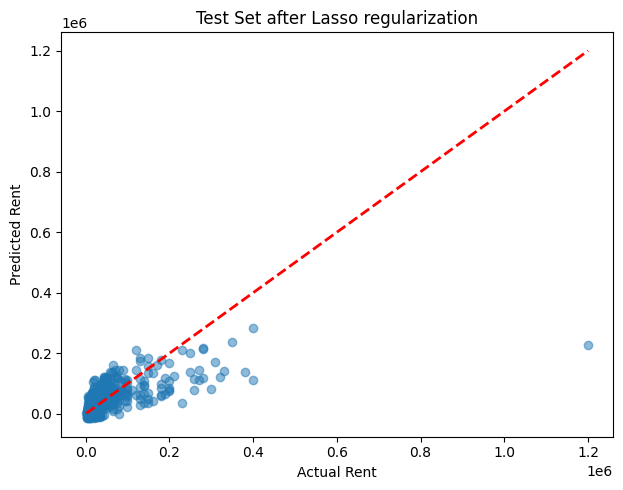

In [1473]:
y_pred_lasso = modelCV.predict(X_test)
y_test = y_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_lasso, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set after Lasso regularization')

plt.tight_layout()
plt.show()

In [1474]:
house.Rent.min()

np.int64(1200)

In [1475]:
# from sklearn.compose import TransformedTargetRegressor
# from sklearn.linear_model import LinearRegression

# # Create a transformer that ensures non-negative predictions
# model_transformed = TransformedTargetRegressor(
#     regressor=LinearRegression(),
#     func=np.exp,       # transform target to exp(y)
#     inverse_func=np.log  # transform predictions back using log
# )


# model_transformed.fit(X_train, y_train)
# train_pred = model_transformed.predict(X_train)
# test_pred = model_transformed.predict(X_test)

In [1476]:
X_train

,BHK,Size,Bathroom,Total_floors,Month,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,...,day_of_week_Wednesday,floor_group_1,floor_group_2,floor_group_3,floor_group_4,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
1995,2,950,2,8,5,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1497,2,800,2,4,6,False,True,True,False,True,...,False,False,True,False,False,False,False,False,False,False
2763,1,545,1,3,6,False,True,False,False,True,...,False,False,True,False,False,False,True,False,False,False
1351,1,465,1,4,7,False,True,True,False,False,...,False,False,True,False,False,False,False,False,False,True
1862,2,900,2,5,7,False,True,False,False,True,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,3,1500,3,2,6,True,False,True,False,False,...,True,False,True,False,False,False,False,True,False,False
466,3,1200,2,3,6,False,True,False,True,True,...,False,False,True,False,False,False,False,False,True,False
3092,2,800,2,17,7,True,False,True,False,False,...,True,False,False,False,False,True,False,False,False,False
3772,3,3500,3,1,5,True,False,True,False,True,...,False,False,True,False,False,True,False,False,False,False


In [1477]:
y_train

1995    23500
1497    10500
2763    19000
1351    20000
1862    17000
        ...  
4426    25000
466     20000
3092    20000
3772    85000
860     25000
Name: Rent, Length: 3796, dtype: int64

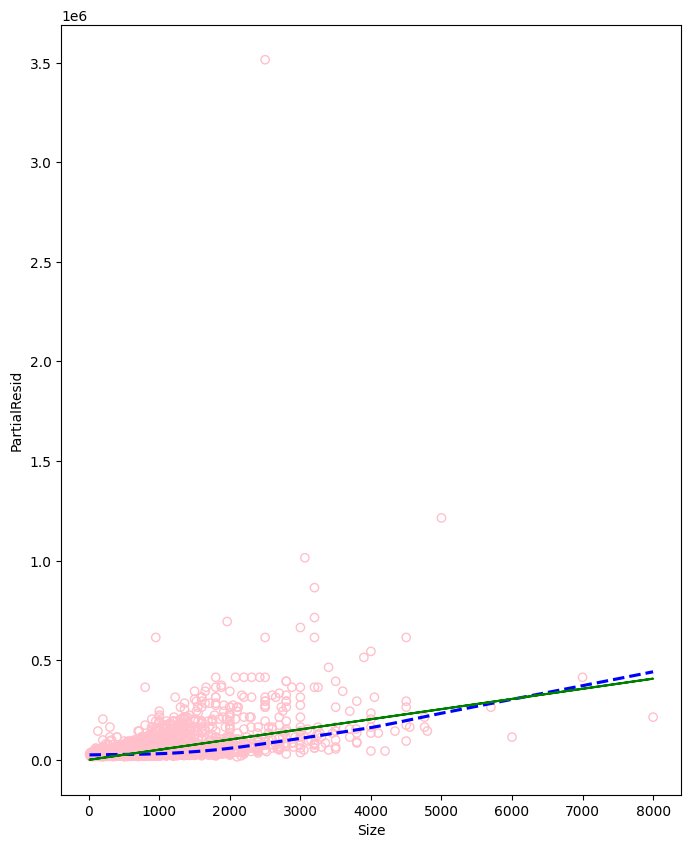

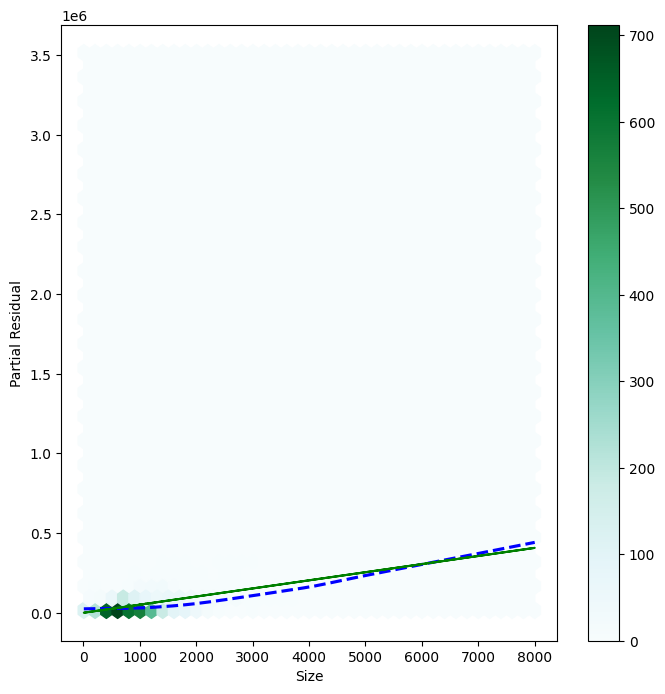

In [1478]:
predictor1 = "Size"
X = house[[predictor1]]   # predictor
y = house['Rent']     # response variable

# add intercept
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# get partial residuals
# terms = b_i * X_i (without intercept)
terms = model.params[predictor1] * house[predictor1]
partial_resid = model.resid + terms

# build dataframe for plotting
df = pd.DataFrame({
    predictor1: house[predictor1],
    'Terms': terms,
    'PartialResid': partial_resid
})

# plotting
plt.figure(figsize=(8,10))
plt.scatter(x=df[predictor1], y=df['PartialResid'], facecolors='none', edgecolors='pink')

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')




df.plot.hexbin(x=predictor1, y="PartialResid", gridsize=40, sharex=True, figsize=(8,8))

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')

%matplotlib inline

plt.xlabel(predictor1)
plt.ylabel("Partial Residual")
plt.show()

In [1479]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Rent   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     978.7
Date:                Thu, 18 Sep 2025   Prob (F-statistic):          1.69e-195
Time:                        22:24:31   Log-Likelihood:                -59756.
No. Observations:                4746   AIC:                         1.195e+05
Df Residuals:                    4744   BIC:                         1.195e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.428e+04   1883.269     -7.584      0.000    -1.8e+04   -1.06e+04
Size          50.9316      1.628     31.285      0.000      47.740      54.123
==============================================================================
Omnibus:                    11550.341   Durbin-Watson:                   1.696
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        240308034.166
Skew:                          24.958   Prob(JB):                         0.00
Kurtosis:                    1104.236   Cond. No.                     2.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [1480]:
model.params
terms

0        56024.806880
1        40745.314095
2        50931.642618
3        40745.314095
4        43291.896225
            ...      
4741     50931.642618
4742    101863.285236
4743     89130.374582
4744     76397.463927
4745     50931.642618
Name: Size, Length: 4746, dtype: float64

In [1481]:
model.resid

0      -31742.366160
1       -6462.873374
2      -19649.201898
3      -16462.873374
4      -21509.455505
            ...     
4741   -21649.201898
4742   -58580.844516
4743   -39847.933862
4744   -17115.023207
4745   -21649.201898
Length: 4746, dtype: float64

<Axes: xlabel='Size', ylabel='Rent'>

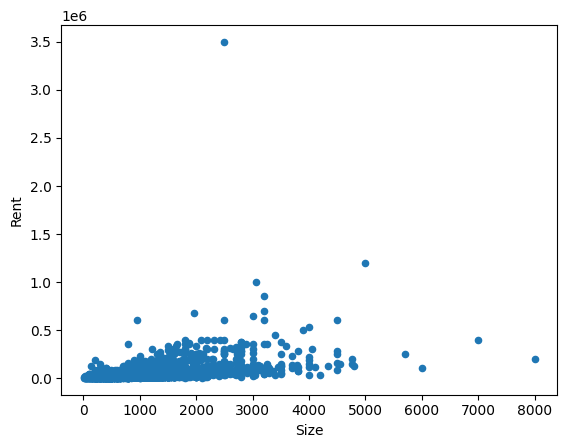

In [1482]:
house.plot.scatter(x="Size", y="Rent")

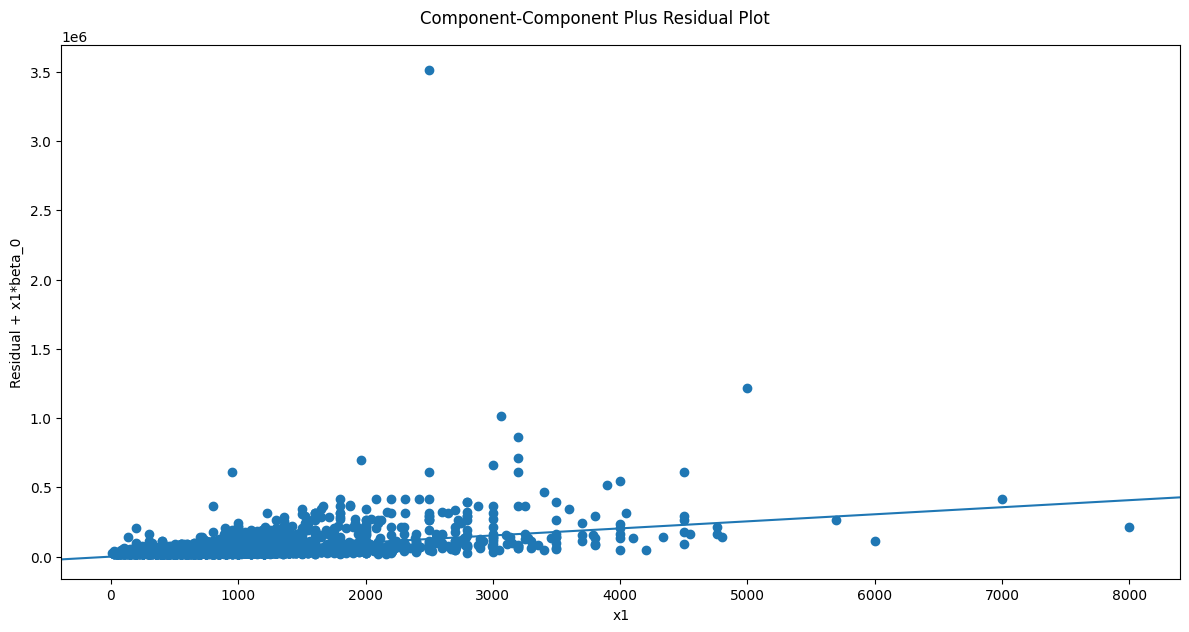

In [1483]:
predictors = ['Size']
outcome = "Rent"


house_outlier = sm.OLS(house[outcome].values, house[predictors].assign(const=1).values)
model_OLS = house_outlier.fit()


fig = plt.figure(figsize=(12, 12))
fig = sm.graphics.plot_ccpr_grid(model_OLS, fig=fig)


Test Main model Metrics:
MSE: 2108071077.81
RMSE: 45913.74
MAE: 22109.82
R2 Score: 0.4710
Adjusted R2 0.45791099956929915

Cross-validation scores: [ 0.51358819  0.16182249  0.20603974  0.17292061 -1.24724196]
Average CV score: -0.0386 (+/- 1.2363)
-20138.865664507386


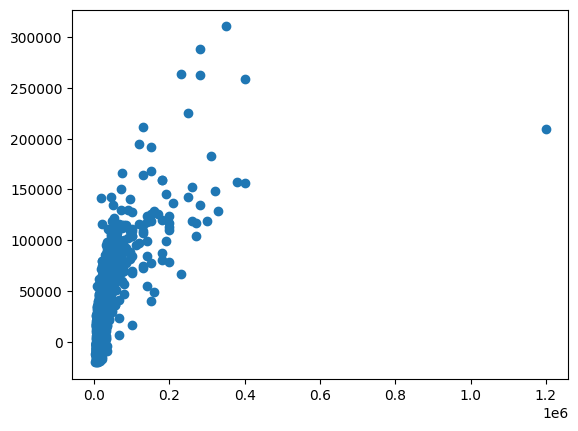

In [1484]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)


# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test Main model")
adjusted_r2(y_test, test_pred, X.shape[1])

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print(test_pred.min())

plt.scatter(x=y_test, y=test_pred)

In [1485]:
print(f'Intercept: {model_main.intercept_:.3f}')

pd.DataFrame({
    "name": X_train.columns,
    "coef": model_main.coef_
})

Intercept: 6837.432


,name,coef
0,BHK,1838.258242
1,Size,25.892395
2,Bathroom,13348.042562
3,Total_floors,878.364146
4,Month,-2878.916560
5,Area Type_Carpet Area,14870.241526
6,Area Type_Super Area,6874.587182
7,Furnishing Status_Semi-Furnished,-14437.141263
8,Furnishing Status_Unfurnished,-12125.949849
9,Tenant Preferred_Bachelors/Family,2080.127778


In [1486]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Month")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Month Metrics:
MSE: 2119775264.86
RMSE: 46041.02
MAE: 22243.02
R2 Score: 0.4681
Adjusted R2 0.45548930058523773

Cross-validation scores: [ 0.51179444  0.16081103  0.20912597  0.17254433 -1.2840371 ]
Average CV score: -0.0460 (+/- 1.2648)


In [1487]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Floor group")
adjusted_r2(y_test, test_pred, len(predictors))


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Floor group Metrics:
MSE: 2126924376.37
RMSE: 46118.59
MAE: 22152.78
R2 Score: 0.4663
Adjusted R2 0.4606349663615339

Cross-validation scores: [ 0.51897013  0.16228852  0.21970666  0.17608864 -1.20233291]
Average CV score: -0.0251 (+/- 1.2058)


In [1488]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Total floors")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Total floors Metrics:
MSE: 2149073368.81
RMSE: 46358.10
MAE: 22572.53
R2 Score: 0.4608
Adjusted R2 0.447963440963431

Cross-validation scores: [ 0.50050232  0.15711607  0.16483506  0.14801121 -1.31550222]
Average CV score: -0.0690 (+/- 1.2747)


In [1489]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
MSE: 2150189081.78
RMSE: 46370.13
MAE: 22275.50
R2 Score: 0.4605
Adjusted R2 0.45415398285704767

Cross-validation scores: [ 0.49922376  0.15808246  0.18849984  0.15980736 -1.09995452]
Average CV score: -0.0189 (+/- 1.1112)


In [1490]:
# Create feature matrix X and target vector y
predictors = ['Size', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
MSE: 2277361088.52
RMSE: 47721.70
MAE: 22382.07
R2 Score: 0.4286
Adjusted R2 0.4273645255981988

Cross-validation scores: [ 0.44696046  0.13345911  0.27449788  0.14561873 -1.61059042]
Average CV score: -0.1220 (+/- 1.5056)


In [1491]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)


model_log = LinearRegression()

y_train_log = np.log1p(y_train)   # log(1 + y), чтобы избежать проблем с нулями
model_log.fit(X_train, y_train_log)

# предсказание
y_pred_log = model_log.predict(X_test)
y_pred = np.expm1(y_pred_log)


print_metrics(y_test, y_pred, "Test w/o Floor group")
adjusted_r2(y_test, y_pred, X.shape[1])



Test w/o Floor group Metrics:
MSE: 1894442756.28
RMSE: 43525.20
MAE: 13848.36
R2 Score: 0.5247
Adjusted R2 0.5128453727527522


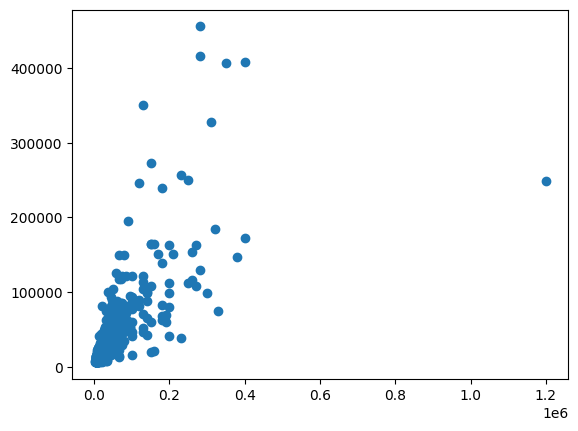

In [1492]:
plt.scatter(x=y_test, y=y_pred)

In [1493]:

gamma = GammaRegressor(alpha=0, max_iter=100000)
gamma.fit(X_train, y_train)
y_pred_gamma = gamma.predict(X_test)

print_metrics(y_test, y_pred_gamma, "Test w/o Floor group")
adjusted_r2(y_test, y_pred_gamma, X.shape[1])


Test w/o Floor group Metrics:
MSE: 1869501453.73
RMSE: 43237.73
MAE: 15471.83
R2 Score: 0.5309
Adjusted R2 0.5192590112241762


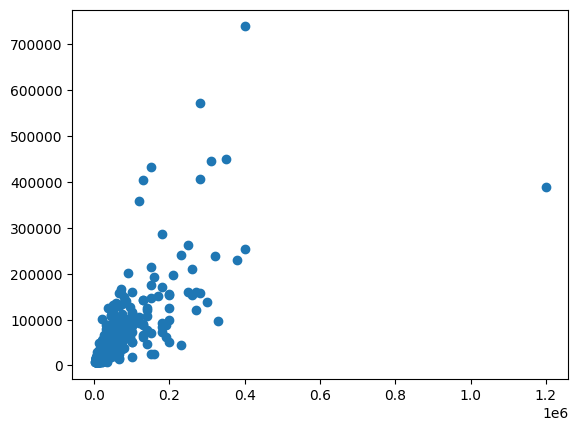

In [1494]:
plt.scatter(y_test, y_pred_gamma)